# Synthesis: model structure matters

Almost any SIR model can be fitted to an epidemic curve, so a good fit on its own tells you very little. What we actually want from a model is a reason to believe one intervention will beat another, and that only comes out right when the model's structure matches the way the disease spreads. Each of the three case studies makes this case for a different transmission mode. Here we put them next to each other.

In [1]:
# walk up to the repo root so `simulation` imports resolve from any subfolder
import sys, pathlib
_root = pathlib.Path.cwd()
while not (_root / "simulation").exists() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from simulation import compartmental as cm
from simulation import plotting, metrics
from simulation.grid import ABMParams, InterventionSettings, run_ensemble
from simulation.agents import State

plotting.use_house_style()

## Three different tempos

Put each case study's chosen model on the same axis and the curves barely look like the same kind of event. COVID-19 spikes early and high, pushed along by airborne spread and a short generation time. Cholera peaks a little later and lower, once bacteria have built up in the water. Ebola stays low and drags on for most of a year, held back by its long incubation period.

In [2]:
# re-run each case study's chosen model so the notebook is self-contained

# waterborne cholera, SIRB, R0 = 1.7 fit to PAHO
# beta solved from R0 = beta*xi*N / (kappa*gamma*delta)
N_ch = 330_000
beta_ch = 1.70 * (0.05 * N_ch) * 0.20 * 0.50 / (0.00625 * N_ch)
chol = cm.SIRB(cm.SIRBParams(beta_ch, 0.20, 0.00625, 0.50, 0.05 * N_ch), N_ch)
chol_out = chol.simulate([N_ch - 20, 20, 0, 18], 365, 366)

# airborne COVID, SIRD; mu gives a 0.7% fatality ratio, beta gives R0 = 2.5
N_co = 1_000_000
g_co = 1 / 6.0; mu_co = 0.007 * g_co / 0.993
covid = cm.SIRD(cm.SIRDParams(2.5 * (g_co + mu_co), g_co, mu_co), N_co)
covid_out = covid.simulate([N_co - 100, 100, 0, 0], 220, 221)

# direct-contact Ebola, SEAIQR, R0 = 1.6 fit to WHO cumulative data
# beta solved from R0 = beta/gamma * (eta*(1-rho) + rho), with q = 0
N_eb = 38_000
g_eb = 1 / 7.0
beta_eb = 1.6 * g_eb / (0.3 * 0.3 + 0.7)
ebola = cm.SEAIQR(cm.SEAIQRParams(beta_eb, 1 / 11.0, g_eb, rho=0.7, eta=0.3, q=0.0), N_eb)
ebola_out = ebola.simulate([N_eb - 5, 0, 0, 5, 0, 0], 500, 501)
print("re-simulated all three case studies")

re-simulated all three case studies


Cholera (waterborne)     peak infectious fraction = 0.070 on day 58
COVID-19 (airborne)      peak infectious fraction = 0.233 on day 38
Ebola (direct contact)   peak infectious fraction = 0.022 on day 257


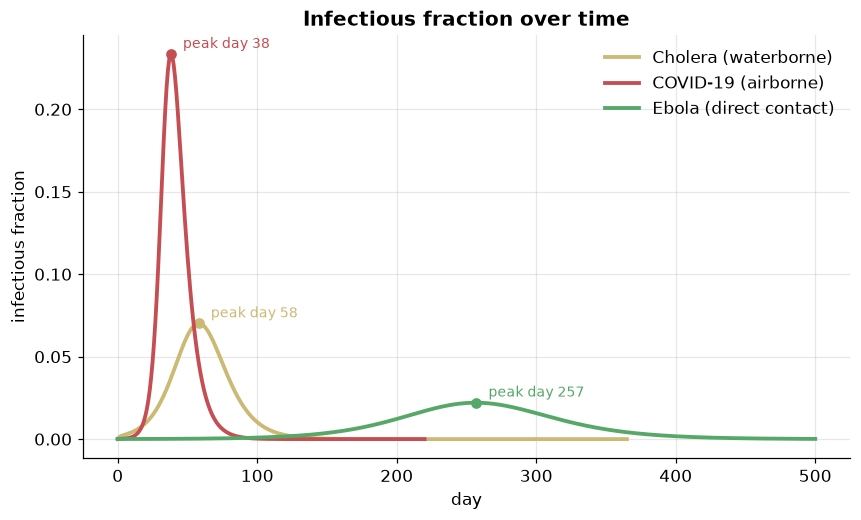

In [3]:
# infectious fraction on a shared axis; dot marks each peak
series = [
    ("Cholera (waterborne)",   chol_out,  N_ch, plotting.PALETTE["B"]),
    ("COVID-19 (airborne)",    covid_out, N_co, plotting.PALETTE["I"]),
    ("Ebola (direct contact)", ebola_out, N_eb, plotting.PALETTE["R"]),
]

fig, ax = plt.subplots(figsize=(9, 5))
for label, df, N, colour in series:
    frac = df["I"] / N
    ax.plot(df.index, frac, color=colour, lw=2.5, label=label)
    pk, day = metrics.peak(df["I"], df.index)
    ax.plot(day, pk / N, "o", color=colour, ms=6)
    ax.annotate(f"peak day {day:.0f}", (day, pk / N),
                textcoords="offset points", xytext=(8, 4), fontsize=9, color=colour)
    print(f"{label:24s} peak infectious fraction = {pk / N:.3f} on day {day:.0f}")

ax.set_xlabel("day"); ax.set_ylabel("infectious fraction")
ax.set_title("Infectious fraction over time")
ax.legend(loc="upper right")

## Which model, and why

Each transmission mode pushed us toward a different model structure, and toward a different intervention as the one worth reaching for. The table below lays that out: the model we settled on, what sets the pace of the outbreak, and the control that does the most work.

In [4]:
selection = pd.DataFrame([
    {"transmission": "waterborne", "case study": "cholera, Peru 1991",
     "chosen model": "SIRB", "R0": round(chol.r0(), 2),
     "what sets the pace": "reservoir build-up (shed -> decay)",
     "key intervention": "sanitation / water treatment (WASH)"},
    {"transmission": "airborne", "case study": "COVID-19 first wave",
     "chosen model": "SIRD / SEAIQR", "R0": round(covid.r0(), 2),
     "what sets the pace": "short generation, latent + asymptomatic",
     "key intervention": "vaccination + sustained distancing"},
    {"transmission": "direct contact", "case study": "Ebola, W. Africa 2014",
     "chosen model": "SEAIQR", "R0": round(ebola.r0(), 2),
     "what sets the pace": "long (~11 day) incubation period",
     "key intervention": "rapid case isolation / contact tracing"},
]).set_index("transmission")
selection

,case study,chosen model,R0,what sets the pace,key intervention
transmission,,,,,
waterborne,"cholera, Peru 1991",SIRB,1.7,reservoir build-up (shed -> decay),sanitation / water treatment (WASH)
airborne,COVID-19 first wave,SIRD / SEAIQR,2.5,"short generation, latent + asymptomatic",vaccination + sustained distancing
direct contact,"Ebola, W. Africa 2014",SEAIQR,1.6,long (~11 day) incubation period,rapid case isolation / contact tracing


## Intervention effectiveness depends on mechanism

Here we take one intervention, isolating 60% of detected cases, and run it against all three mechanisms in the agent-based model, then measure how much it cuts the final attack rate. The pattern tracks the biology. Isolation helps a great deal when someone has to be physically present to pass the infection on, and does almost nothing when the source can infect people from across the room.

waterborne      attack 0.73 -> 0.33  (55% reduction)


airborne        attack 0.95 -> 0.86  (9% reduction)


direct contact  attack 0.64 -> 0.37  (43% reduction)


Text(0.5, 1.0, 'Attack-rate reduction from isolating 60% of cases')

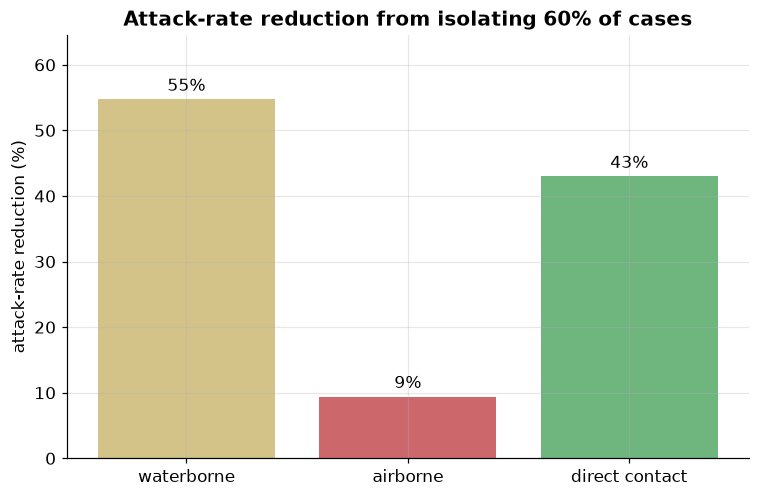

In [5]:
setups = {
    "waterborne": dict(grid_size=80, n_agents=2500, mechanism="waterborne",
        params=ABMParams(infect_prob=0.9, shed_rate=3.0, decay=0.2, kappa=2.0,
                         recovery_prob=0.06, step_prob=0.85), n_infected=10, base_seed=100),
    "airborne": dict(grid_size=80, n_agents=2500, mechanism="airborne",
        params=ABMParams(infect_prob=0.18, radius=2.0, recovery_prob=0.12,
                         step_prob=0.85), n_infected=10, base_seed=100),
    "direct contact": dict(grid_size=50, n_agents=3000, mechanism="contact",
        params=ABMParams(infect_prob=0.25, recovery_prob=0.08, step_prob=0.8),
        n_infected=10, base_seed=50),
}
isolate = InterventionSettings(quarantine_fraction=0.6, quarantine_delay=2)

# attack rate = fraction ever infected (1 - final S). Compare no intervention
# against isolating 60% of cases, and report the drop as a percentage.
reductions = {}
for name, kw in setups.items():
    base, _ = run_ensemble(6, 80, **kw)
    iso, _ = run_ensemble(6, 80, interventions=isolate, **kw)
    nag = kw["n_agents"]
    a_base = 1 - base[-1, State.SUSCEPTIBLE] / nag
    a_iso = 1 - iso[-1, State.SUSCEPTIBLE] / nag
    reductions[name] = 100 * (a_base - a_iso) / a_base
    print(f"{name:15s} attack {a_base:.2f} -> {a_iso:.2f}  ({reductions[name]:.0f}% reduction)")

# one bar per mechanism, coloured as in the tempo plot; labels show the value
fig, ax = plt.subplots()
colours = [plotting.PALETTE["B"], plotting.PALETTE["I"], plotting.PALETTE["R"]]
bars = ax.bar(list(reductions), list(reductions.values()), color=colours, alpha=0.85)
ax.bar_label(bars, fmt="%.0f%%", padding=3, fontsize=11)
ax.set_ylim(0, max(reductions.values()) * 1.18)
ax.set_ylabel("attack-rate reduction (%)")
ax.set_title("Attack-rate reduction from isolating 60% of cases")

## Conclusion

The bar chart makes the argument on its own. Isolating cases roughly halves the attack rate when spread is waterborne or by direct contact, and barely moves it for airborne spread, where an isolated person still infects whoever is nearby.

So the model has to change with the disease. Take away cholera's environmental reservoir and water treatment and sanitation have nothing to push against. COVID-19 only becomes interesting once you add death, vaccination, and a latent and asymptomatic structure, since that is what lets you weigh lockdowns, vaccines, and quarantine against each other. Ebola needs the exposed compartment to reproduce its slow build-up and to show why isolation bites there.

Getting that structure right is most of the modelling work. See `conclusions.md` for the full write-up.